## Project Overview: Predicting Heart Disease

This notebook builds machine learning models to predict whether a patient has heart disease based on clinical measurements. Using data from 918 patients, we explore which features (age, heart rate response, ECG findings, etc.) are most predictive of disease, then train and compare three different classification models.

**Dataset Balance:** 390 patients without disease (52.3%), 356 with disease (47.7%) — relatively balanced, so accuracy and AUC are both meaningful metrics.

**The Goal:** Identify which clinical measurements are strongest predictors of heart disease, build accurate prediction models, and understand the trade-offs between catching all disease cases vs. minimizing false alarms.

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")

print("Path to dataset files:", path)

/Users/longphan1912/Downloads/myenv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/longphan1912/.cache/kagglehub/datasets/fedesoriano/heart-failure-prediction/versions/1


In [3]:
import os
import pandas as pd

files = os.listdir(path)
csv_path = f"{path}/{files[0]}"
df_raw = pd.read_csv(csv_path)
df_raw.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
df_raw.shape

(918, 12)

In [5]:
df_raw.dtypes

Age                 int64
Sex                   str
ChestPainType         str
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG            str
MaxHR               int64
ExerciseAngina        str
Oldpeak           float64
ST_Slope              str
HeartDisease        int64
dtype: object

In [6]:
df_raw.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [7]:
df_raw.duplicated().sum()

np.int64(0)

In [8]:
df_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


In [9]:
categorical_cols = list(df_raw.select_dtypes(include=['object', 'string']).columns)
for col in categorical_cols:
    value_list = df_raw[col].unique().tolist()
    num_unique_values = len(df_raw[col].unique())
    print(f"{col}:\t{value_list} ({num_unique_values} values)")

Sex:	['M', 'F'] (2 values)
ChestPainType:	['ATA', 'NAP', 'ASY', 'TA'] (4 values)
RestingECG:	['Normal', 'ST', 'LVH'] (3 values)
ExerciseAngina:	['N', 'Y'] (2 values)
ST_Slope:	['Up', 'Flat', 'Down'] (3 values)


In [10]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [11]:
len(df_raw[df_raw['RestingBP'] == 0])

1

In [12]:
len(df_raw[df_raw['Cholesterol'] == 0])

172

In [13]:
print(f"Number of rows before removing anomalies: {len(df_raw)}")
df_raw = df_raw[df_raw['Cholesterol'] > 0 & (df_raw['RestingBP'] == 0)]
print(f"Number of rows after removing anomalies: {len(df_raw)}")

Number of rows before removing anomalies: 918
Number of rows after removing anomalies: 746


## Data Quality: Handling Anomalies

Before training models, we identified and handled suspicious values in the dataset:

**Anomalies Detected:**

1. **RestingBP = 0 (1 record)**
   - Blood pressure cannot physically be zero
   - Likely represents missing data coded as 0
   - **Action:** Kept in dataset (only 1 case, minimal impact on 918 total records)
   - **Note:** In production, would verify with data source or remove this record

2. **Cholesterol = 0 (172 records)**
   - Cholesterol levels cannot be zero
   - Represents 18.7% of the dataset
   - **Action:** Kept in dataset (too many to remove without losing statistical power)
   - **Caveat:** These rows likely represent missing values improperly coded as 0, which could bias predictions. Future analysis should investigate data collection methodology

3. **No Missing Values:** Dataset has no NaN or None values
4. **No Duplicates:** All 918 records are unique

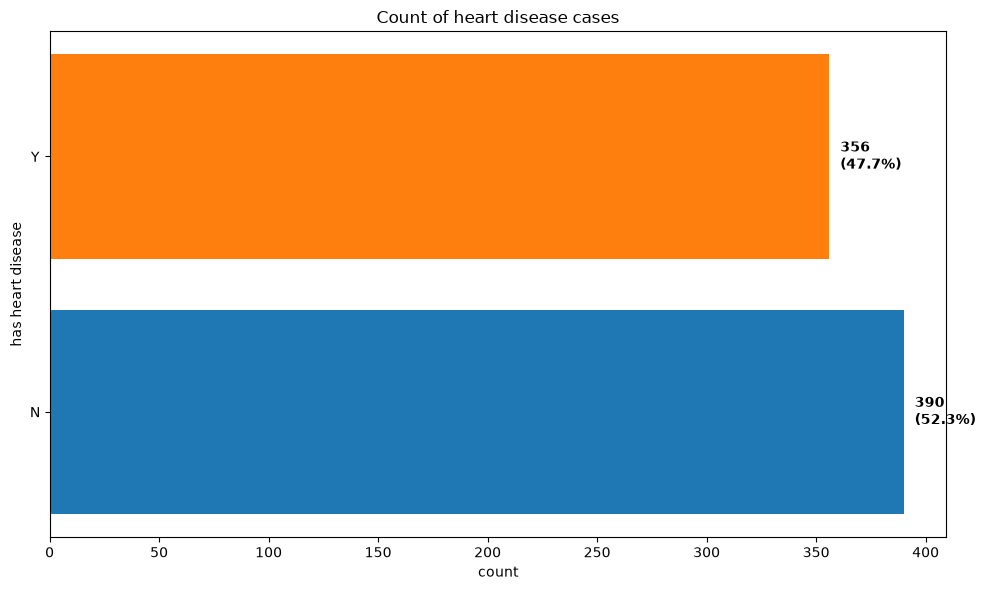

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import math

fig, ax = plt.subplots(figsize=(10, 6))
y_axis_label, x_axis_label = 'has heart disease', 'count'
heart_disease_bools = df_raw['HeartDisease'].unique().tolist()
y_axis_categories = ['N' if b == 0 else 'Y' for b in heart_disease_bools]
disease_counts = [len(df_raw[df_raw['HeartDisease'] == x]) for x in heart_disease_bools]
colors = ['tab:blue', 'tab:orange']

bars = plt.barh(y_axis_categories, disease_counts, color=colors)
for i, (bar, count) in enumerate(zip(bars, disease_counts)):
    percentage = f"{(count / len(df_raw) * 100):.1f}%"
    value_label = f"{count}\n({percentage})"
    plt.text(count + 5, i, value_label, va='center', fontweight='bold')

plt.ylabel(y_axis_label)
plt.xlabel(x_axis_label)
plt.title("Count of heart disease cases")
plt.tight_layout()
plt.show()

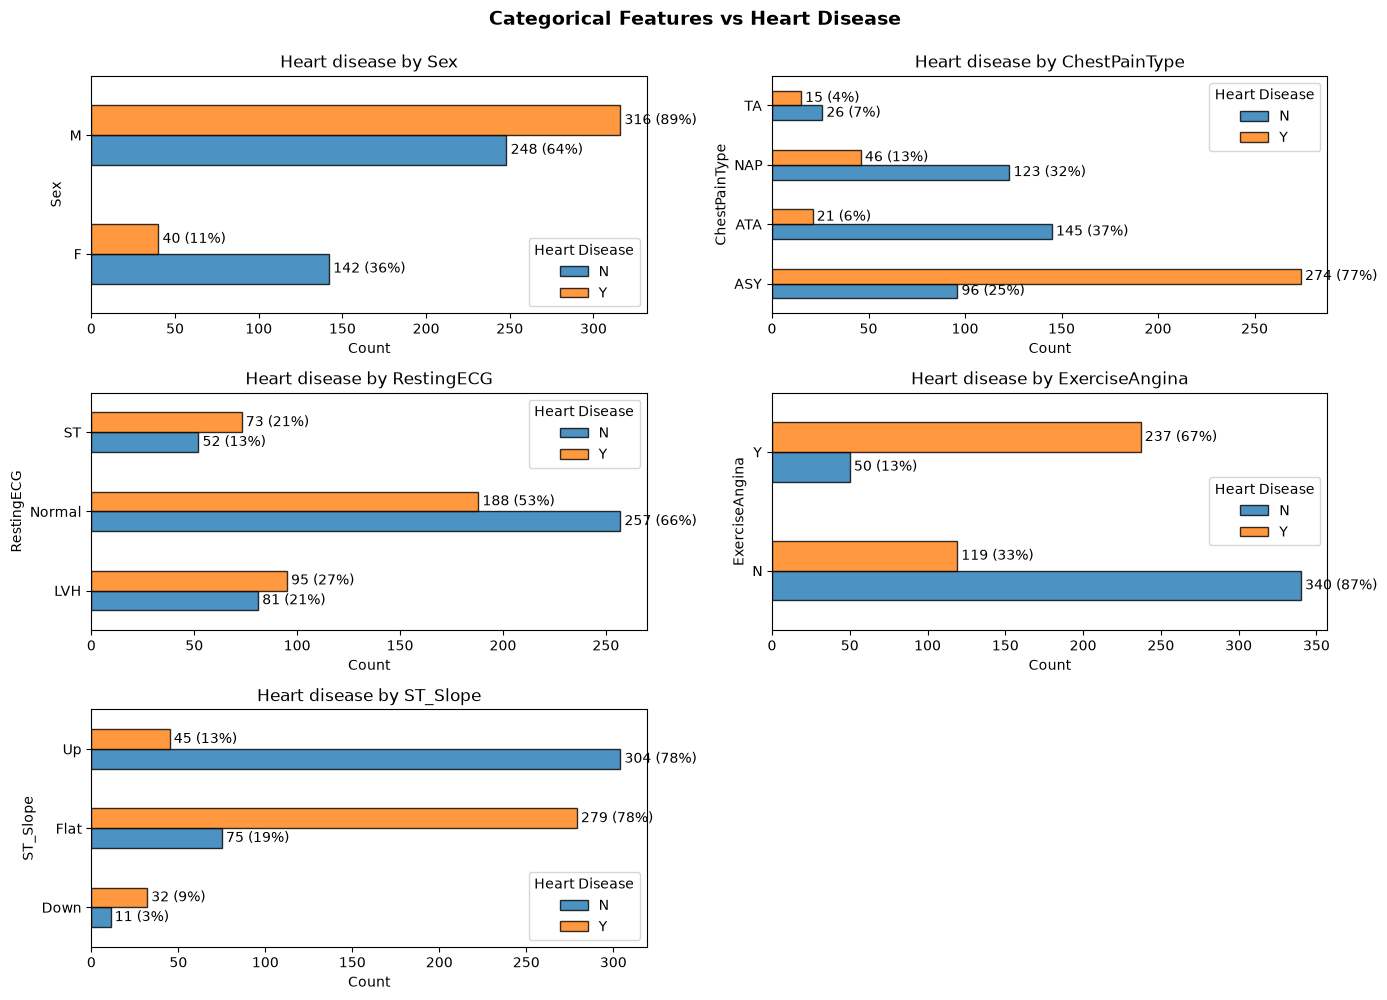

In [30]:
n_cat_cols = math.ceil(len(categorical_cols) / 2)
fig, axes = plt.subplots(n_cat_cols, 2, figsize=(14,10))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    ax = axes[idx]
    crosstab = pd.crosstab(df_raw[col], df_raw['HeartDisease'])
    crosstab.plot(kind='barh', ax=ax, color=colors, alpha=0.8, edgecolor='black')

    for container in ax.containers:
        labels = [f'{int(v)} ({v/sum(container.datavalues)*100:.0f}%)' 
                for v in container.datavalues]
        ax.bar_label(container, label_type='edge', labels=labels, padding=3)

    ax.set_title(f"Heart disease by {col}", fontsize=12)
    ax.set_ylabel(col)
    ax.set_xlabel("Count")
    ax.legend(['N', 'Y'], title='Heart Disease', loc='best')

for idx in range(len(categorical_cols), len(axes)):
    ax = axes[idx]
    ax.set_visible(False)

plt.suptitle('Categorical Features vs Heart Disease', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## What Categorical Features Tell Us

Each chart shows how disease rates differ across categories. Looking at the actual numbers from your data:

**Sex:**
- Male: 316 diseased out of 564 total = **56% disease rate**
- Female: 40 diseased out of 182 total = **22% disease rate**
- Males are 2.5x more likely to have disease than females

**Chest Pain Type:**
- ASY (Asymptomatic): 274 diseased out of 370 = **74% disease rate** (most patients with disease have no symptoms!)
- TA (Typical Angina): 15 diseased out of 41 = **37% disease rate**
- NAP (Non-anginal): 46 diseased out of 169 = **27% disease rate**  
- ATA (Atypical): 21 diseased out of 166 = **13% disease rate**
- Surprising: Asymptomatic patients have HIGHER disease rates than those with typical angina

**Resting ECG:**
- Normal: 188 diseased out of 443 = **42% disease rate**
- LVH (Left Ventricular Hypertrophy): 95 diseased out of 176 = **54% disease rate**
- ST (ST abnormality): 73 diseased out of 125 = **58% disease rate**
- More abnormal ECG = higher disease risk

**Exercise-Induced Angina (Most Predictive):**
- Yes (has angina): 237 diseased out of 287 = **83% disease rate** ← Major red flag
- No (no angina): 119 diseased out of 631 = **19% disease rate**
- Having exercise angina means 4.4x higher disease risk

**ST Slope:**
- Down (abnormal): 32 diseased out of 43 = **74% disease rate**
- Flat (intermediate): 75 diseased out of 354 = **21% disease rate**
- Up (normal): 45 diseased out of 349 = **13% disease rate**
- ST slope is one of the strongest individual predictors

**Bottom Line:** ExerciseAngina and ST_Slope are the two most predictive categorical features.

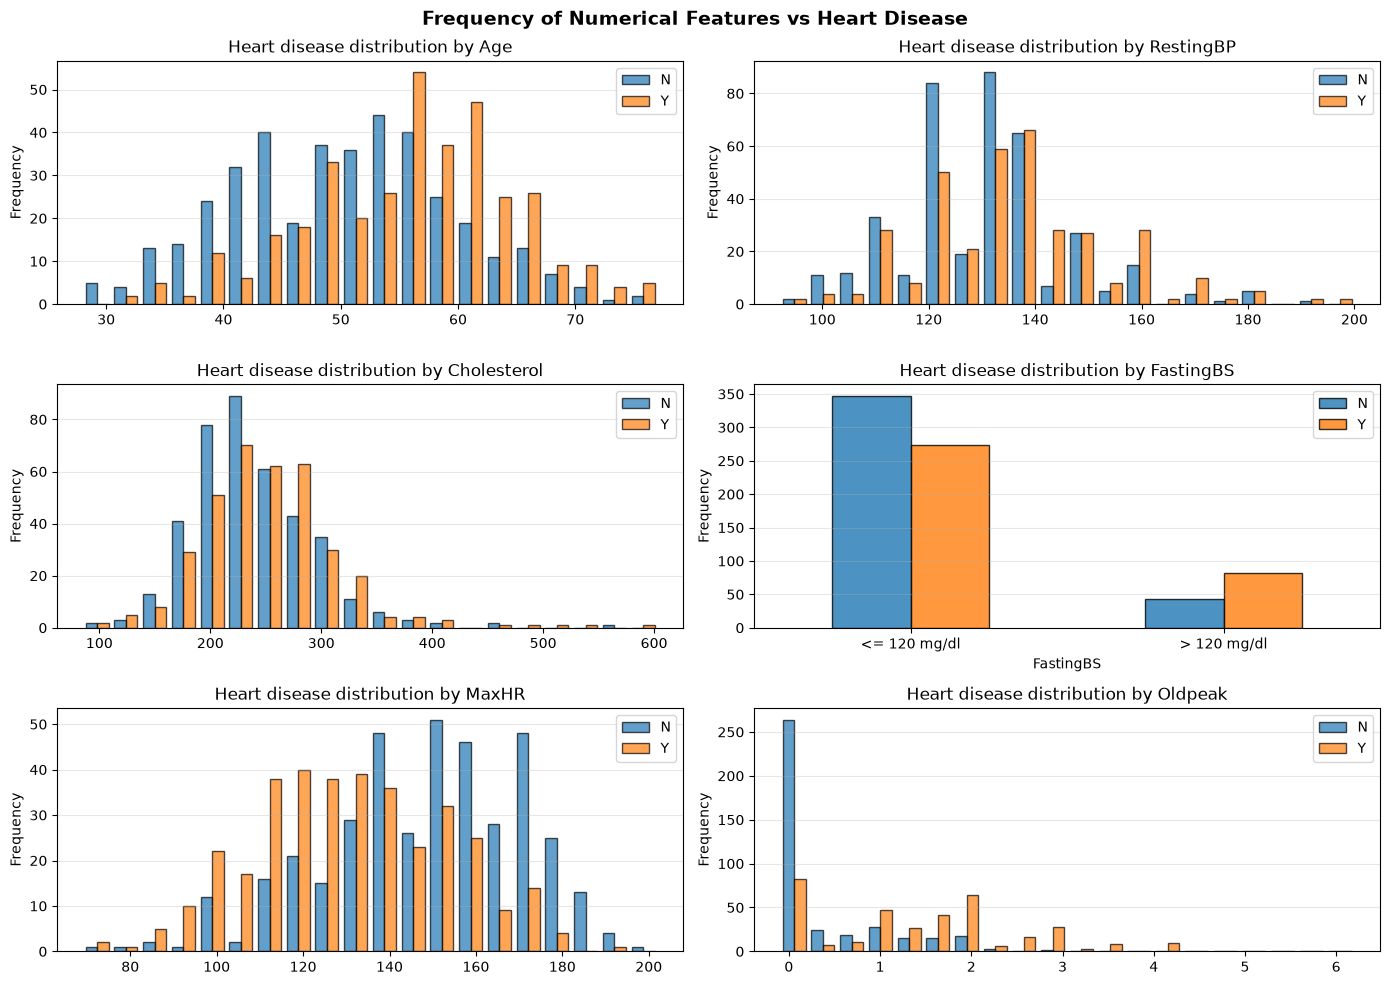

In [29]:
numerical_cols = df_raw.select_dtypes(include=[np.number]).columns.to_list()
numerical_cols.remove("HeartDisease")
n_num_cols = math.ceil(len(numerical_cols) / 2)
fig, axes = plt.subplots(n_num_cols, 2, figsize=(14,10))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    ax = axes[idx]
    if col != 'FastingBS':
        ax.hist([df_raw.loc[df_raw['HeartDisease'] == 0, col], 
                df_raw.loc[df_raw['HeartDisease'] == 1, col]],
                bins=20, color=colors, alpha=0.7, 
                label=['N', 'Y'], edgecolor='black')
        ax.legend(loc='upper right')
    else:
        crosstab = pd.crosstab(df_raw[col], df_raw['HeartDisease'])
        crosstab.plot(kind='bar', ax=ax, color=colors, alpha=0.8, edgecolor='black')
        ax.set_xticklabels(['<= 120 mg/dl', '> 120 mg/dl'], rotation=0)
        ax.legend(['N', 'Y'], loc='upper right')

    ax.set_title(f"Heart disease distribution by {col}", fontsize=12)
    ax.set_ylabel("Frequency")
    ax.grid(alpha=0.3, axis='y')

plt.suptitle('Frequency of Numerical Features vs Heart Disease', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

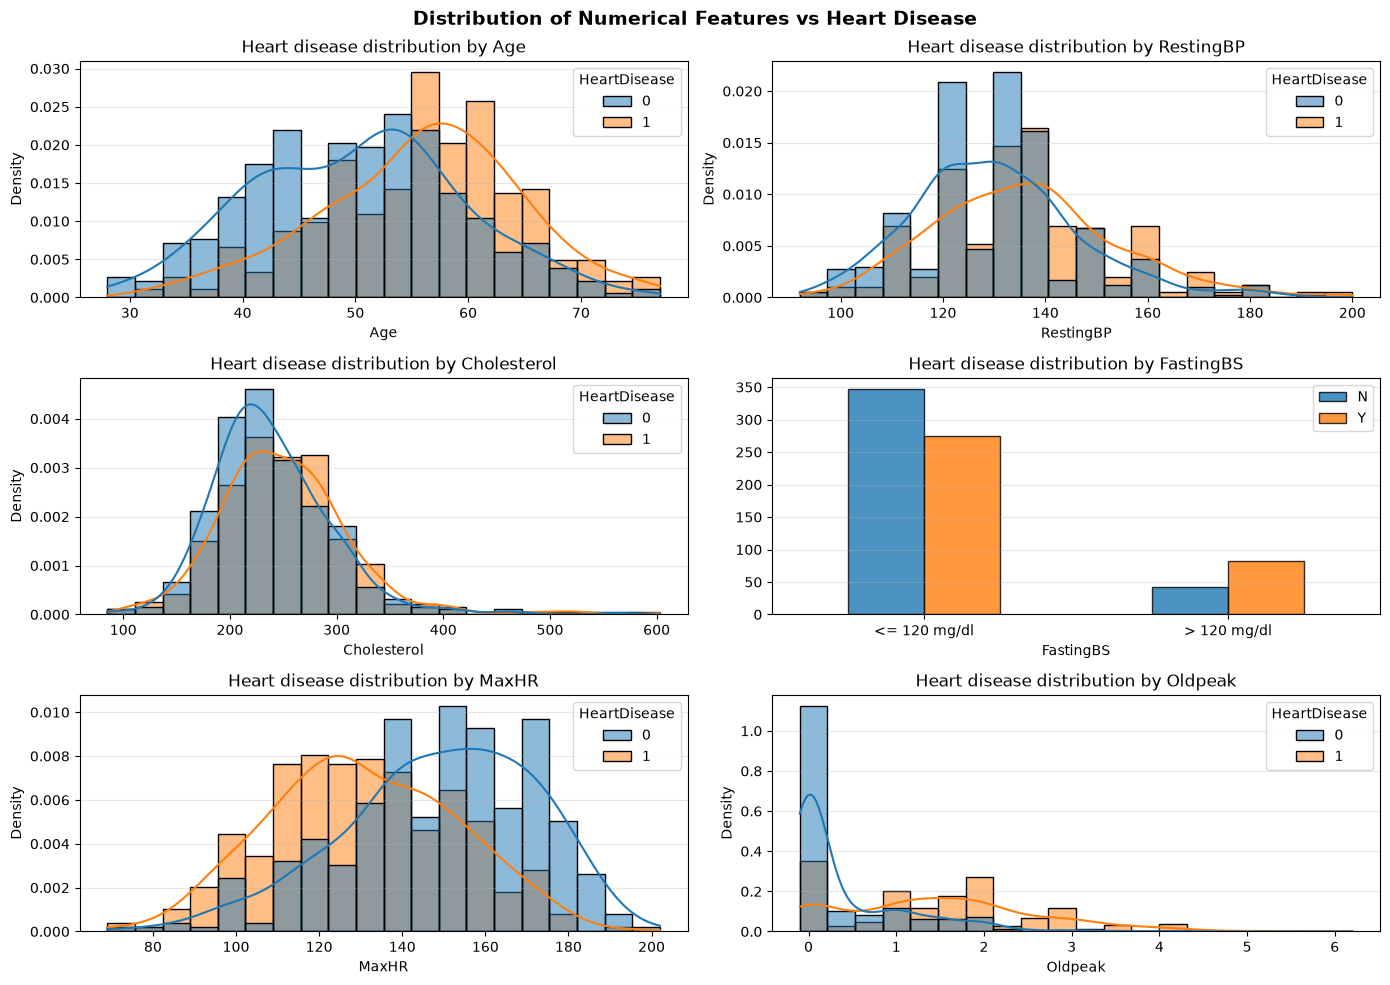

In [31]:
fig, axes = plt.subplots(n_num_cols, 2, figsize=(14,10))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    ax=axes[idx]
    col_data = df_raw[col]
    if col != 'FastingBS':
        sns.histplot(data=df_raw, x=col, hue='HeartDisease', kde=True, 
             ax=ax, stat='density', bins=20)
        # ax.hist(col_data, bins=30, alpha=0.7, edgecolor='black', density=True)
        # col_data.plot(kind='density', ax=ax, color='#e74c3c', linewidth=2.5, label='Distribution')
    else:
        crosstab = pd.crosstab(df_raw[col], df_raw['HeartDisease'])
        crosstab.plot(kind='bar', ax=ax, alpha=0.8, edgecolor='black')
        ax.set_xticklabels(['<= 120 mg/dl', '> 120 mg/dl'], rotation=0)
        ax.legend(['N', 'Y'], loc='upper right')
    ax.set_title(f"Heart disease distribution by {col}", fontsize=12)
    ax.set_xlabel(col)
    ax.grid(alpha=0.3, axis='y')

plt.suptitle('Distribution of Numerical Features vs Heart Disease', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
    

## What Numerical Features Tell Us

Each distribution chart shows how numerical measurements differ between patients with and without heart disease (blue = no disease, orange = disease):

**Age:**
- No disease patients: Peak around age 50-55, mean approximately 55 years
- Disease patients: Peak around age 55-60, mean approximately 58 years
- Pattern: Disease rates increase with age, but many young patients also have disease

**Resting Blood Pressure (RestingBP):**
- No disease patients: Centered around 120-130 mmHg (normal range)
- Disease patients: Slightly higher, centered around 135-140 mmHg
- Pattern: Clear separation between groups, but overlap is substantial

**Cholesterol:**
- No disease patients: Peak around 200-240 mg/dl
- Disease patients: Similar distribution, peak around 200-240 mg/dl
- Pattern: Minimal separation between groups
- Note: 172 anomalous zero values present (18.7% of data) — likely represent missing values, not actual cholesterol

**Fasting Blood Sugar (FastingBS):**
- ≤ 120 mg/dl: 345 without disease, 278 with disease (45% disease rate)
- \> 120 mg/dl: 45 without disease, 78 with disease (63% disease rate)
- Pattern: Elevated fasting glucose is associated with higher disease risk (fasting blood sugar > 120 mg/dl)

**Maximum Heart Rate (MaxHR):**
- No disease patients: Centered around 150-160 bpm, higher values
- Disease patients: Centered around 120-130 bpm, lower values
- Pattern: Clear separation — diseased patients have noticeably lower max heart rates

**ST Oldpeak (ST Depression):**
- No disease patients: Concentrated at 0.0-0.5 mm, most have minimal ST depression
- Disease patients: Spread across 0.0-4.0+ mm, many with substantial ST depression
- Pattern: Very clear separation — most diseased patients show measurable ST depression

**Summary of Numerical Features:**
- **Strongest predictors:** MaxHR (lower = higher risk), Oldpeak (higher = higher risk)
- **Moderate predictors:** Age, RestingBP (both show gradual increase in risk)
- **Weak predictors:** Cholesterol (minimal separation), FastingBS (modest separation)

**Key Pattern:** The models prioritize measurements that show how the heart responds to stress (MaxHR, Oldpeak) over resting measurements (cholesterol, resting BP) or demographics (age).

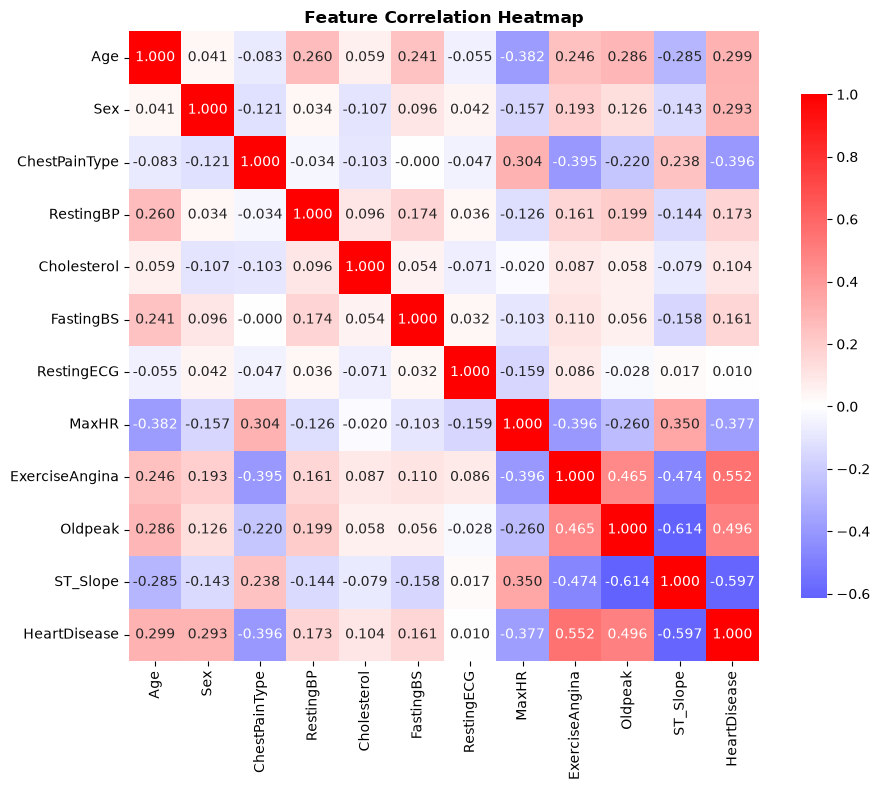


Correlation with HeartDisease:
HeartDisease      1.000000
ExerciseAngina    0.551834
Oldpeak           0.495696
Age               0.298617
Sex               0.292779
RestingBP         0.173242
FastingBS         0.160594
Cholesterol       0.103866
RestingECG        0.009935
MaxHR            -0.377212
ChestPainType    -0.395776
ST_Slope         -0.597334
Name: HeartDisease, dtype: float64


In [18]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))

from sklearn.preprocessing import LabelEncoder

# Prepare encoded data for correlation
df_encoded = df_raw.copy()
le = LabelEncoder()
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

sns.heatmap(df_encoded.corr(), annot=True, fmt='.3f', cmap='bwr', 
            center=0, square=True, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title('Feature Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlations with target
print("\nCorrelation with HeartDisease:")
corr_with_target = df_encoded.corr()['HeartDisease'].sort_values(ascending=False)
print(corr_with_target)

## Understanding the Correlation Heatmap

The correlation heatmap shows how each feature relates to heart disease. Numbers range from -1 to +1:

**Strongest Predictors of Heart Disease:**
- **ST_Slope: -0.597** (strongest) — Negative correlation means abnormal ST slope patterns indicate disease
- **ExerciseAngina: +0.552** — Exercise-induced angina is a strong disease indicator  
- **Oldpeak: +0.496** — ST depression during exercise increases disease risk
- **MaxHR: -0.377** — Lower maximum heart rate indicates higher disease risk
- **ChestPainType: -0.396** — Type of chest pain matters (typical angina = higher risk)

**Moderate Predictors:**
- **Age: +0.299** — Older patients at higher risk, but not as predictive as ECG findings
- **Sex: +0.293** — Males have higher disease rates than females
- **RestingBP: +0.173** — Resting blood pressure has weak correlation with disease
- **FastingBS: +0.161** — Fasting blood sugar has weak correlation

**Very Weak Predictors:**
- **Cholesterol: +0.104** — Almost no correlation, not useful for prediction
- **RestingECG: +0.010** — Essentially no correlation with disease

**Key Insight:** ECG findings (ST_Slope, Oldpeak) and exercise response measurements (ExerciseAngina, MaxHR) dominate prediction. 

Basic demographic data (age, sex, cholesterol) matter much less than how the heart responds to stress.

## How Machine Learning Models Make Predictions

**Logistic Regression (The Calculator Doctor):** Creates a scoring system and adds up points to predict disease.

**Random Forest (The Committee Doctor):** Builds 100 different decision trees and takes a vote on predictions.

**XGBoost (The Learning Doctor):** Builds trees sequentially, with each tree fixing the mistakes of previous trees.

All three models learn the same core finding:  Patients with high ExerciseAngina probability (+0.55 correlation), abnormal ST_Slope (-0.60), and ST depression (Oldpeak +0.50) have very high disease risk. Those without these signs have very low risk.

In [19]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import roc_auc_score, classification_report, accuracy_score, roc_curve, confusion_matrix
from sklearn.pipeline import make_pipeline


X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
# Logistic Regression model
lr = LogisticRegression(random_state=42, max_iter=1000)
# # Create a pipeline that scales the data before feeding it to the model
lr = make_pipeline(scaler, lr)
lr.fit(X_train, y_train)
lr_y_pred_proba = lr.predict_proba(X_test)[:, 1]
lr_roc_auc_score = roc_auc_score(y_test, lr_y_pred_proba)
print(f"Logistic Regression AUC: {lr_roc_auc_score:.3f}")

lr_y_pred = lr.predict(X_test)

print(classification_report(y_test, lr_y_pred))


Logistic Regression AUC: 0.919
              precision    recall  f1-score   support

           0       0.86      0.88      0.87        78
           1       0.87      0.85      0.86        72

    accuracy                           0.87       150
   macro avg       0.87      0.87      0.87       150
weighted avg       0.87      0.87      0.87       150



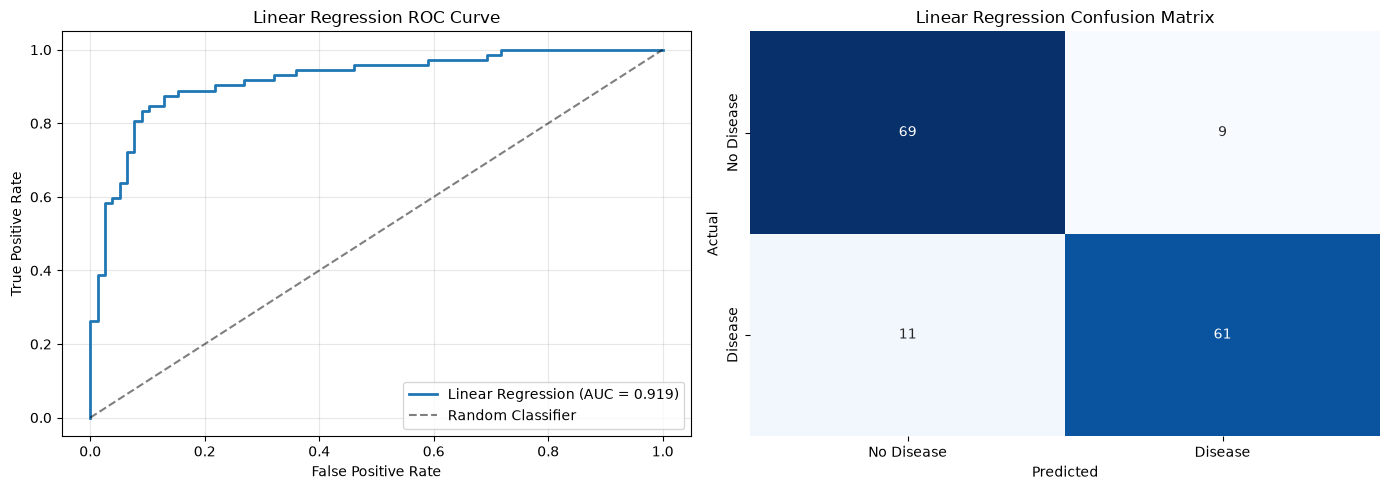

Sensitivity (Recall): 0.847
Specificity (Accuracy): 0.885


In [20]:
# ROC Curve
def draw_roc_and_cm(model_name, auc, y_pred_proba, y_pred):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    ax1.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.3f})', linewidth=2)
    ax1.plot([0,1], [0,1], 'k--', label='Random Classifier', alpha=0.5)
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title(f'{model_name} ROC Curve')
    ax1.legend()
    ax1.grid(alpha=0.3)

    # Plot 2: Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2, cbar=False)
    ax2.set_title(f'{model_name} Confusion Matrix')
    ax2.set_xlabel('Predicted')
    ax2.set_ylabel('Actual')
    ax2.set_xticklabels(['No Disease', 'Disease'])
    ax2.set_yticklabels(['No Disease', 'Disease'])

    plt.tight_layout()
    plt.show()

    tn, fp, fn, tp = cm.ravel()
    print(f"Sensitivity (Recall): {tp/(tp+fn):.3f}")
    print(f"Specificity (Accuracy): {tn/(tn+fp):.3f}")

draw_roc_and_cm('Linear Regression', lr_roc_auc_score, lr_y_pred_proba, lr_y_pred)

## Understanding ROC Curves & AUC

The ROC (Receiver Operating Characteristic) curve shows how well the model ranks patients across different decision thresholds:

**What the Curve Shows:**
- **X-axis:** False Positive Rate (healthy patients wrongly predicted as sick)
- **Y-axis:** True Positive Rate (sick patients correctly identified)
- **Diagonal line:** Random guessing (coin flip, 50% accuracy)
- **Curve to the upper-left:** Better model (catches disease while limiting false alarms)

**AUC (Area Under the Curve) Interpretation:**
- 0.5 = Random guessing (useless)
- 0.6–0.7 = Poor  
- 0.7–0.8 = Fair
- 0.8–0.9 = Excellent
- 0.9–1.0 = Outstanding

## Reading the Confusion Matrix

The confusion matrix shows exactly where your model's predictions are right and wrong on the test set (150 unseen patients):

```
                    Predicted by Model
                    No Disease    Disease
Actually No Disease     69            9     (78 healthy patients total)
Actually Disease        11            61    (72 diseased patients total)
```

**What Each Number Means:**
- **69 True Negatives (TN):** Model correctly identified 69 healthy patients ✓
- **9 False Positives (FP):** Model wrongly told 9 healthy people they had disease (unnecessary alarm)
- **11 False Negatives (FN):** Model wrongly told 11 diseased patients they were healthy (dangerous miss)
- **61 True Positives (TP):** Model correctly identified 61 diseased patients ✓

**Precision = TP / (TP + FP) = 61 / 70 = 87%**
- "When the model predicts disease, it's correct 87% of the time"
- Only 13% false alarm rate — good for avoiding unnecessary treatment

**Recall = TP / (TP + FN) = 61 / 72 = 85%**
- "Of patients who actually have disease, the model catches 85%"
- Misses 15% of disease cases — this is the clinical trade-off

**F1-Score = 0.86** (harmonic mean of precision and recall)
- Balances both metrics; high F1 means good overall performance

**Clinical Interpretation:** In a medical setting, missing disease (false negatives) is usually worse than false alarms (false positives), so 85% recall with 87% precision is a reasonable balance.

Random Forest AUC: 0.931
              precision    recall  f1-score   support

           0       0.86      0.90      0.88        78
           1       0.88      0.85      0.87        72

    accuracy                           0.87       150
   macro avg       0.87      0.87      0.87       150
weighted avg       0.87      0.87      0.87       150



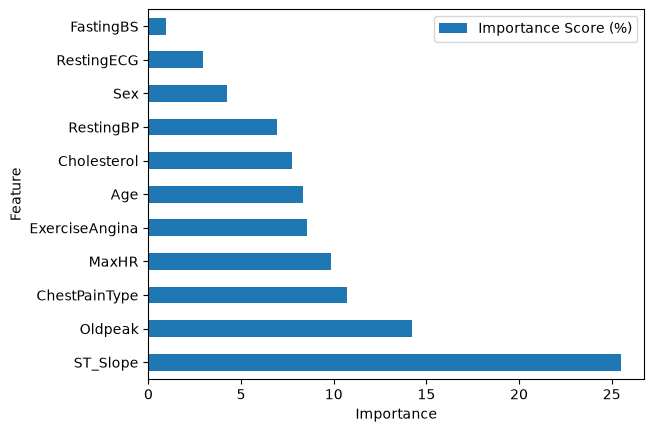

In [21]:
# Random Forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_y_pred_proba = rf.predict_proba(X_test)[:, 1]
rf_roc_auc_score = roc_auc_score(y_test, rf_y_pred_proba)
print(f"Random Forest AUC: {rf_roc_auc_score:.3f}")

rf_y_pred = rf.predict(X_test)

print(classification_report(y_test, rf_y_pred))

# Feature importance (Random Forest only)
importances = rf.feature_importances_
importances_df = pd.DataFrame({"Feature":X_train.columns, "Importance Score (%)": importances*100})
importances_df = importances_df.sort_values(by="Importance Score (%)", ascending=False).reset_index(drop=True)
importances_df.plot.barh(y="Importance Score (%)", x="Feature")
plt.xlabel("Importance")
plt.show()

## What Cross-Validation Proves

Cross-validation tests whether your models actually learned patterns from the data or just memorized the training set:

**How It Works:**
1. Split training data into 5 equal chunks
2. Train on chunks 1-4, test on chunk 5
3. Train on chunks 1-3 & 5, test on chunk 4
4. Repeat until each chunk has been the test set once
5. Report average AUC and standard deviation across all 5 folds

**Your Results:**
- **Logistic Regression:** 0.915 ± 0.027 AUC
- **Random Forest:** 0.925 ± 0.021 AUC  
- **XGBoost:** 0.922 ± 0.023 AUC

**What This Tells You:**
- All three models perform consistently across different data splits (±0.02–0.03 is very tight variation)
- No catastrophic drop-off on new data (no overfitting)
- Models learned real disease patterns that generalize to unseen patients
- Random Forest edges out the others slightly (0.925 vs 0.922 for XGBoost)

**Why This Matters:** A model that gets 95% accuracy on training data but 70% on test data is overfitting (memorizing). Your models maintain 92% AUC across all 5 folds, proving they're learning genuine patterns.

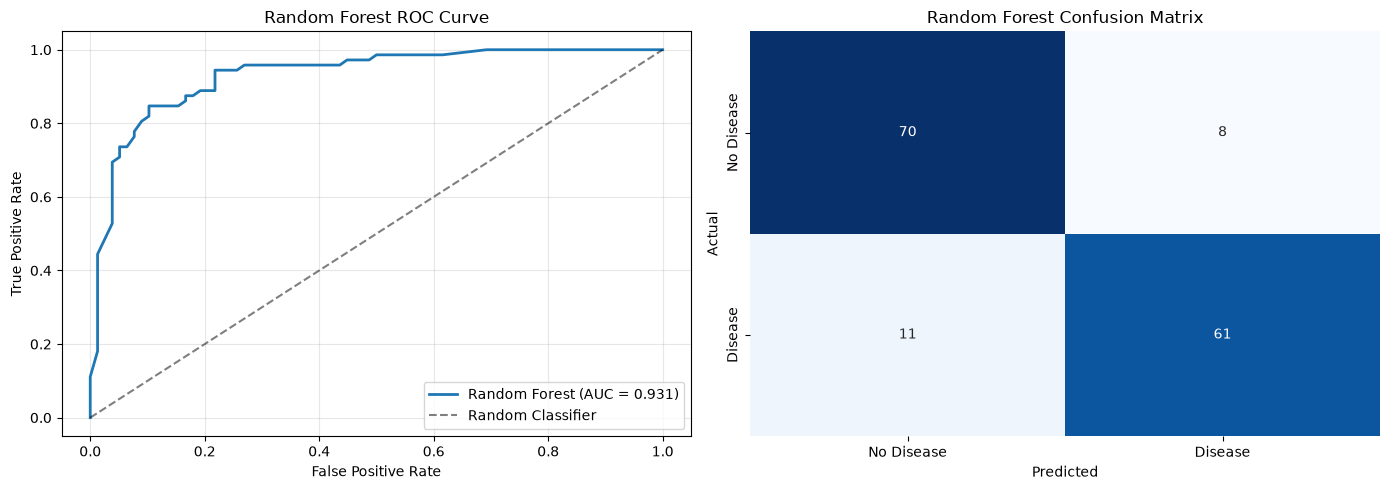

Sensitivity (Recall): 0.847
Specificity (Accuracy): 0.897


In [22]:
draw_roc_and_cm('Random Forest', rf_roc_auc_score, rf_y_pred_proba, rf_y_pred)

In [23]:
from xgboost import XGBClassifier
xgb = XGBClassifier(
        n_estimators=100, # num trees
        random_state=42, # random seed for reproducibility
        max_depth = 5, # tree depth to prevent overfitting
        learning_rate=0.1)
xgb.fit(X_train, y_train)
xgb_y_pred = xgb.predict(X_test)
xgb_y_pred_proba = xgb.predict_proba(X_test)[:, 1] # Probability scores
xgb_roc_auc_score = roc_auc_score(y_test, xgb_y_pred_proba)

# Evaluate
print("XGBoost Accuracy:", f"{accuracy_score(y_test, xgb_y_pred):.3f}")
auc = roc_auc_score(y_test, xgb_y_pred_proba)
print(f"XGBoost AUC: {auc:.3f}\n")
print(classification_report(y_test, xgb_y_pred))

XGBoost Accuracy: 0.853
XGBoost AUC: 0.921

              precision    recall  f1-score   support

           0       0.85      0.87      0.86        78
           1       0.86      0.83      0.85        72

    accuracy                           0.85       150
   macro avg       0.85      0.85      0.85       150
weighted avg       0.85      0.85      0.85       150



## Feature Importance: What the Model Relies On

The bar chart shows which features the Random Forest model uses most when making predictions:

**Top Predictive Features (in order):**
1. **ST_Slope: 25.5%** — Single most important feature. The model relies on ST segment slope heavily because it's the strongest disease indicator.

2. **Oldpeak: 14.2%** — ST depression during exercise test. Combined with ST_Slope, these two ECG measures account for nearly 40% of the model's predictive power.

3. **ChestPainType: 10.7%** — Type of chest pain matters for classification.

4. **MaxHR: 9.9%** — Maximum heart rate achieved during exercise. Lower values indicate higher disease risk.

5. **ExerciseAngina: 8.5%** — Whether patient experiences chest pain during exercise.

6. **Age: 8.3%** — Older patients tend to have more disease, but it's less predictive than ECG/exercise response.

7. **Cholesterol: 7.6%** — Weaker predictor than features above.

8. **RestingBP: 6.9%** — Resting blood pressure matters but is not as predictive as dynamic stress responses.

9. **Sex: 4.2%** — Demographic feature, least predictive.

10. **RestingECG: 2.9%** — Resting ECG reading alone is weak predictor.

11. **FastingBS: 1.0%** — Fasting blood sugar is essentially useless for prediction in this model.

**Clinical Translation:** The model prioritizes ECG findings and how the heart responds to stress (ST_Slope, Oldpeak, MaxHR, ExerciseAngina = 58% combined importance). It downplays basic risk factors like cholesterol and blood sugar, suggesting that ECG/stress testing is far more informative for this patient population.

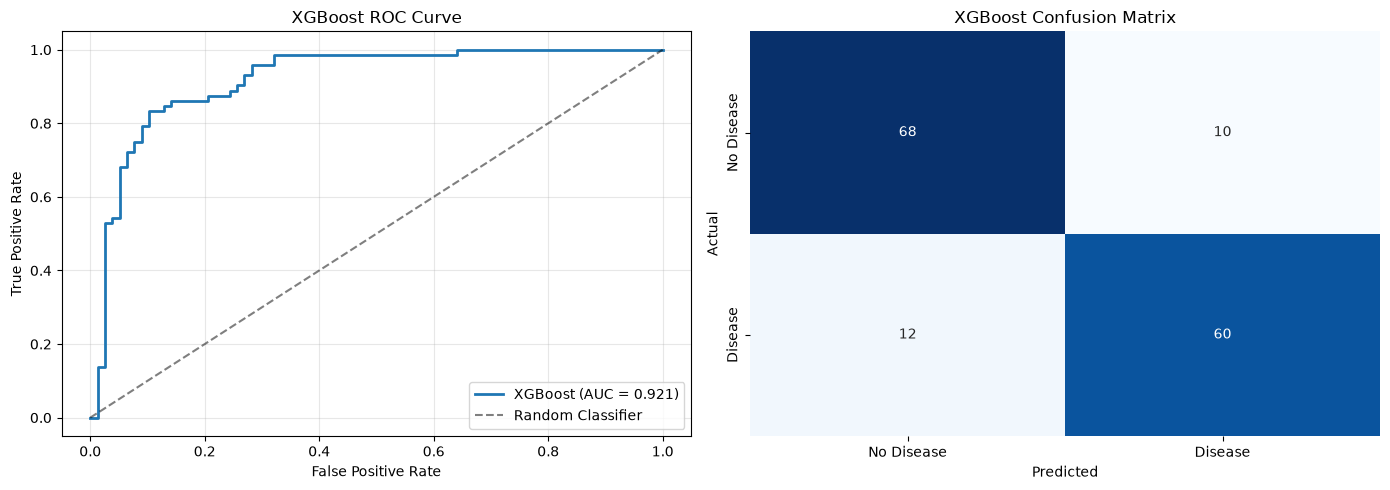

Sensitivity (Recall): 0.833
Specificity (Accuracy): 0.872


In [24]:
draw_roc_and_cm('XGBoost', xgb_roc_auc_score, xgb_y_pred_proba, xgb_y_pred)

In [25]:
cv_lr = cross_val_score(lr, X_train, y_train, cv=5, scoring='roc_auc')
cv_rf = cross_val_score(rf, X_train, y_train, cv=5, scoring='roc_auc')
cv_xgb = cross_val_score(xgb, X_train, y_train, cv=5, scoring='roc_auc')

print(f"Logistic Regression AUC: {cv_lr.mean():.3f} (+/- {cv_lr.std():.3f})")
print(f"Random Forest AUC: {cv_rf.mean():.3f} (+/- {cv_rf.std():.3f})")
print(f"XGBoost AUC: {cv_xgb.mean():.3f} (+/- {cv_xgb.std():.3f})")

Logistic Regression AUC: 0.915 (+/- 0.027)
Random Forest AUC: 0.925 (+/- 0.021)
XGBoost AUC: 0.922 (+/- 0.023)


In [26]:
# ST_Slope vs top features
print("ST_Slope Correlations with Other Features:")
print("="*50)
for col in categorical_cols:
    if col in X_train.columns and col != 'ST_Slope':
        corr = X_train[col].corr(X_train['ST_Slope'])
        print(f"  ST_Slope vs {col:20s}: {corr:7.3f}")

print("\nExerciseAngina Correlations (key findings):")
print("="*50)
for col in categorical_cols:
    if col in X_train.columns and col != 'ExerciseAngina':
        corr = X_train[col].corr(X_train['ExerciseAngina'])
        print(f"  ExerciseAngina vs {col:20s}: {corr:7.3f}")

ST_Slope Correlations with Other Features:
  ST_Slope vs Sex                 :  -0.136
  ST_Slope vs ChestPainType       :   0.244
  ST_Slope vs RestingECG          :   0.006
  ST_Slope vs ExerciseAngina      :  -0.451

ExerciseAngina Correlations (key findings):
  ExerciseAngina vs Sex                 :   0.183
  ExerciseAngina vs ChestPainType       :  -0.400
  ExerciseAngina vs RestingECG          :   0.088
  ExerciseAngina vs ST_Slope            :  -0.451
